In [78]:
import torch
import torch.nn as nn 
import tiktoken 

from ridgeline.measurement.benchmark import benchmark
from ridgeline.measurement.trace import peak_memory, trace_ops

In [79]:
class MultiHeadAttention(nn.Module): 
  def __init__(self, d_in, d_out, context_length, drop_rate, n_heads, qkv_bias=False): 
    super().__init__()
    self.d_in = d_in
    self.d_out = d_out
    self.context_length = context_length
    self.drop_rate = drop_rate
    self.n_heads = n_heads
    self.head_dim = d_out // n_heads 

    # weight matrices: (8, 16), PyTorch converts to (16, 8) by default
    self.W_Q = nn.Linear(d_in, d_out, bias=qkv_bias)                    
    self.W_K = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_V = nn.Linear(d_in, d_out, bias=qkv_bias)

    # mask fill 
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1).bool())

    # dropout 
    self.dropout = nn.Dropout(drop_rate)

    # output projection 
    self.out_proj = nn.Linear(d_out, d_out)

    # kv cache 
    self.kv_cache = None

  def prefill(self, x, use_cache=True):
    batch, num_tokens, _ = x.shape

    # compute q,k,v and reshape matrices
    keys = self.W_K(x).view(batch, num_tokens, self.n_heads, self.head_dim).transpose(2, 1)
    values = self.W_V(x).view(batch, num_tokens, self.n_heads, self.head_dim).transpose(2, 1)

    return keys, values 

  def decode(self, x):
    batch, num_tokens, _ = x.shape 
    # compute k, v for new tokens
    keys = self.W_K(x[:,-1:,:]).view(batch, 1, self.n_heads, self.head_dim).transpose(2, 1)
    values = self.W_V(x[:,-1:,:]).view(batch, 1, self.n_heads, self.head_dim).transpose(2, 1)

    # append to cache 
    cached_keys, cached_values = self.kv_cache
    keys = torch.cat([cached_keys, keys], dim=2)
    values = torch.cat([cached_values, values], dim=2)

    return keys, values 

  def forward(self, x, use_cache=True):
    batch, num_tokens, _ = x.shape 
    queries = self.W_Q(x).view(batch, num_tokens, self.n_heads, self.head_dim).transpose(2, 1)

    if self.kv_cache is None:     
      keys, values = self.prefill(x)
    else: 
      keys, values = self.decode(x)

    # update cache 
    self.kv_cache = (keys, values)

    # attention score 
    attn_score = queries @ keys.transpose(-2, -1)
    scaled_score = attn_score / (self.head_dim ** 0.5)

    # offset 
    offset = keys.shape[2] - num_tokens 

    # applying causal attention with attention mask 
    scaled_score = scaled_score.masked_fill(self.mask[offset : offset+num_tokens, : keys.shape[2]], float("-inf"))


    attn_weight = torch.softmax(scaled_score, dim=-1)
    attn_weight = self.dropout(attn_weight)

    # return context vector
    context_vec = (attn_weight @ values).transpose(1,2).contiguous().view(batch, num_tokens, self.d_out)

    return self.out_proj(context_vec) 

In [80]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
    self.eps = 1e-5

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False) 
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift 

class FeedForward(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Linear(emb_dim, 4 * emb_dim), 
      nn.GELU(approximate='tanh'),
      nn.Linear(emb_dim * 4, emb_dim), 
    )
  
  def forward(self, x):
    return self.layers(x)

In [81]:
from torch.nn import Dropout

class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.attn = MultiHeadAttention(
      d_in=cfg["emb_dim"],
      d_out=cfg["emb_dim"],
      context_length=cfg["context_length"],
      drop_rate=cfg["drop_rate"],
      n_heads=cfg["n_heads"],
      qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.dropout = Dropout(cfg["drop_rate"])

  def forward(self, x, use_cache=True):
    # sub-layer 1
    shortcut = x
    x = self.norm1(x)
    x = self.attn(x, use_cache=use_cache)
    x = self.dropout(x)
    x = x + shortcut

    # sub-layer 2
    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [82]:
GPT3_CONFIG_125M = {
    "vocab_size": 50257,
    "context_length": 2048,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

In [83]:
class GPT(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.vec_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.layers = nn.Sequential(
      # *, unpacks the list into individual arguments
      *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.lnf = LayerNorm(cfg["emb_dim"])
    self.lm_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, x, use_cache=True):
    batch_size, seq_len = x.shape
    if use_cache and self.layers[0].attn.kv_cache is not None:
      offset = self.layers[0].attn.kv_cache[0].shape[2] 
    else: 
      offset = 0 
    pos = torch.arange(offset, offset + seq_len, device=x.device).unsqueeze(0)
    
    x = self.vec_emb(x) + self.pos_emb(pos)
    x = self.dropout(x)
    for layer in self.layers:
      x = layer(x, use_cache=use_cache)
    x = self.lnf(x)
    logits = self.lm_head(x)
    return logits

In [84]:
def reset_cache(model):
  for layer in model.layers:
    layer.attn.kv_cache = None 
  return

def snapshot_cache(model):
  return [layer.attn.kv_cache for layer in model.layers]

def restore_cache(model, snapshot):
  for layer, cache in zip(model.layers, snapshot):
    layer.attn.kv_cache = cache

def generate(model, idx, max_new_tokens, context_size):
  # reset cache from previous runs 
  reset_cache(model) 

  # prefill, generate tokens 
  logits = model(idx, use_cache=True) 
  next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)  # greedy
  idx = torch.cat([idx, next_token], dim=1)   # append

  # decode, generate 1 tokens at a time 
  for _ in range(max_new_tokens - 1):
    logits = model(next_token, use_cache=True) 
    next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)  # greedy
    idx = torch.cat([idx, next_token], dim=1)   # append
  return idx 

def prefill(model, idx):
  reset_cache(model)
  logits = model(idx, use_cache=True)
  next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)  # greedy
  return next_token

def decode_step(model, token):
  logits = model(token, use_cache=True)
  next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)  # greedy
  return next_token


In [85]:
# Load the pretrained weights — no training in this notebook
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = GPT(GPT3_CONFIG_125M)
model.load_state_dict(torch.load("gpt3_verdict.pth", map_location=device))
model.to(device)
model.eval()
print("loaded pretrained weights")

loaded pretrained weights


In [86]:
enc = tiktoken.get_encoding("gpt2")
prompt = "The sky is blue but its ridiculous beacuse I have never forseen anything like this. The sky is blue but its ridiculous beacuse I have never forseen anything like this."
tokens = enc.encode(prompt)
idx = torch.tensor(tokens).unsqueeze(0).to(next(model.parameters()).device)

# to generate text
model.eval() 
with torch.no_grad():
    out = generate(model, idx, max_new_tokens=50, context_size=256)

decoded = enc.decode(out.squeeze(0).tolist())
print(decoded)

The sky is blue but its ridiculous beacuse I have never forseen anything like this. The sky is blue but its ridiculous beacuse I have never forseen anything like this.











" at the his admirers would have put it--it represented, my lips, my a swelling of muscles, a purblind public. And at the moment I was _the_ fashionable


In [87]:
N = 10
with torch.no_grad():
    out_a = generate(model, idx, max_new_tokens=N, context_size=256)

    next_token = prefill(model, idx)
    out_b = torch.cat([idx, next_token], dim=1)
    for _ in range(N - 1):
        next_token = decode_step(model, next_token)
        out_b = torch.cat([out_b, next_token], dim=1)

# Proved prefill/decode splitting resulted in the same byte-identical tokens to the original generate
print(torch.equal(out_a, out_b))


True


In [88]:
device_str = "mps" if torch.backends.mps.is_available() else "cpu"

with torch.no_grad():
    # TTFT: prefill resets the cache internally, so every call starts clean
    ttft = benchmark(lambda: prefill(model, idx), device_str)

    # TPOT: fix the cache at length L, and re-pin it before every timed call
    # so each iteration decodes token L+1 from a cache of length L, not a
    # growing context.
    next_token = prefill(model, idx)
    cache_snapshot = snapshot_cache(model)

    tpot = benchmark(
        lambda: decode_step(model, next_token),
        device_str,
        setup=lambda: restore_cache(model, cache_snapshot),
    )

    # sanity check: setup() re-pins the cache to length L before each timed call,
    # but the last timed decode_step still grows it by 1, so we expect L + 1.
    # (If restore_cache were broken we'd instead see L + iters.)
    cached_len = model.layers[0].attn.kv_cache[0].shape[2]

print(f"TTFT: {ttft * 1000:.3f} ms")
print(f"TPOT: {tpot * 1000:.3f} ms")
print(f"cache length after benchmarking: {cached_len} (expected: {idx.shape[1] + 1})")


TTFT: 13.054 ms
TPOT: 8.770 ms
cache length after benchmarking: 39 (expected: 39)


In [89]:
with torch.no_grad():
    # prefill memory footprint: full prompt forward pass + allocating the cache.
    # reset first so the "before" baseline isn't polluted by a leftover cache
    # from the previous cell.
    reset_cache(model)
    prefill_bytes = peak_memory(lambda: prefill(model, idx), device_str)

    # decode memory footprint: one decode step on top of an already-populated cache
    next_token = prefill(model, idx)
    decode_bytes = peak_memory(lambda: decode_step(model, next_token), device_str)

print(f"Prefill memory footprint: {prefill_bytes / 1e6:.3f} MB")
print(f"Decode step memory footprint: {decode_bytes / 1e6:.3f} MB")


Prefill memory footprint: 2.866 MB
Decode step memory footprint: 0.203 MB


In [90]:
from ridgeline.measurement.benchmark import benchmark

with torch.no_grad():
  # prefill: each iteration starts from an empty cache
  t_prefill = benchmark(
    lambda: prefill(model, idx),
    device_str,
    setup=lambda: reset_cache(model),
  )

  # decode: populate the cache once, snapshot it,
  # then every iteration decodes at that same cache length
  next_token = prefill(model, idx)
  snap = snapshot_cache(model)
  t_decode = benchmark(
    lambda: decode_step(model, next_token),
    device_str,
    setup=lambda: restore_cache(model, snap),
  )

print(f"prefill: {t_prefill*1000:.2f} ms   decode step: {t_decode*1000:.2f} ms")

prefill: 14.05 ms   decode step: 9.39 ms


In [91]:
with torch.no_grad():
    next_token = prefill(model, idx)
    decode_timings = trace_ops(model, lambda: decode_step(model, next_token), device_str)

# top 15 slowest modules for a single decode step
for name, seconds in sorted(decode_timings.items(), key=lambda kv: -kv[1])[:15]:
    print(f"{seconds * 1000:8.4f} ms  {name}")


 62.1439 ms  model
  7.0112 ms  layers.10
  6.9780 ms  layers.0
  5.3500 ms  layers.2
  4.6744 ms  layers.11
  4.5325 ms  layers.7
  4.5140 ms  layers.9
  4.2773 ms  layers.1
  4.1953 ms  layers.3
  4.1299 ms  layers.8
  3.9777 ms  layers.4
  3.9395 ms  layers.6
  3.8854 ms  layers.5
  2.8126 ms  layers.0.attn
  2.5211 ms  lm_head


FLOPs: 17179869184
median time: 0.005370999999286141 seconds
FLOPs/time: 3198635111949.99 FLOPs/second 

FLOPs: 137438953472
median time: 0.04137639600230614 seconds
FLOPs/time: 3321675320981.07 FLOPs/second 

FLOPs: 463856467968
median time: 0.15147216700279387 seconds
FLOPs/time: 3062321462394.11 FLOPs/second 

FLOPs: 1099511627776
median time: 0.3807564585004002 seconds
FLOPs/time: 2887703158355.87 FLOPs/second 

Bytes: 400000000
Median Time: 0.004403437502332963 seconds
GBs/second: 90.84 GBs/second 

Bytes: 800000000
Median Time: 0.008491603999573272 seconds
GBs/second: 94.21 GBs/second 

Bytes: 1600000000
Median Time: 0.01652327050032909 seconds
GBs/second: 96.83 GBs/second 

Bytes: 3200000000
Median Time: 0.03645668749595643 seconds
GBs/second: 87.78 GBs/second 

prefill  I=17.67 FLOP/B  715.79 GFLOP/s  memory-bound   41.8% of roof  ( 40.5 GB/s effective)
decode   I= 0.50 FLOP/B   28.38 GFLOP/s  memory-bound   58.7% of roof  ( 56.9 GB/s effective)

peak compute   =   3.32 TFLOP/s

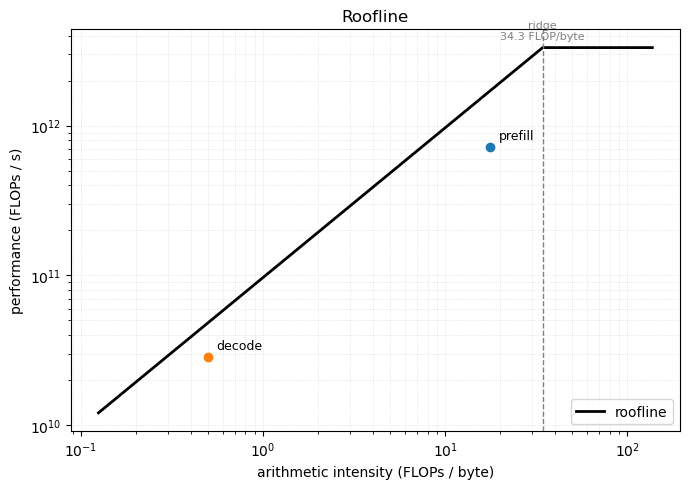

In [92]:
import matplotlib.pyplot as plt
from ridgeline.analytical.flop_byte_model import predict_model
from ridgeline.analytical.roofline import (
    arithmetic_intensity, classify, attainable_flops, plot_roofline,
)
from ridgeline.benchmarks.compute_roof import compute_roof
from ridgeline.benchmarks.memory_roof import memory_roof

cfg = GPT3_CONFIG_125M
DTYPE_BYTES = 4  # the model runs in fp32, so predicted bytes count 4 per element

# --- 1. measured device ceilings: best achieved across each sweep ---
# compute_roof uses fp16 matmuls; both phases here sit far left of the ridge
# (memory-bound), so the flat roof's exact height doesn't change the verdict.
peak_flops = max(compute_roof(N, device_str) for N in [2048, 4096, 6144, 8192])
peak_bandwidth = max(memory_roof(N, device_str)
                     for N in [50_000_000, 100_000_000, 200_000_000, 400_000_000])

# --- 2. measure the two phases (TTFT = prefill, TPOT = one decode step) ---
prompt_len = idx.shape[1]
with torch.no_grad():
    ttft = benchmark(lambda: prefill(model, idx), device_str,
                     setup=lambda: reset_cache(model))
    tok = prefill(model, idx)
    snap = snapshot_cache(model)
    tpot = benchmark(lambda: decode_step(model, tok), device_str,
                     setup=lambda: restore_cache(model, snap))

# --- 3. analytical predictions per phase ---
pre = predict_model(cfg, batch=1, query_len=prompt_len, ctx_len=prompt_len,     dtype_bytes=DTYPE_BYTES)
dec = predict_model(cfg, batch=1, query_len=1,          ctx_len=prompt_len + 1, dtype_bytes=DTYPE_BYTES)

# --- 4. place each phase on the roofline ---
points = []
for name, pred, t in [("prefill", pre, ttft), ("decode", dec, tpot)]:
    intensity = arithmetic_intensity(pred["flops"], pred["bytes"])
    achieved  = pred["flops"] / t                      # FLOPs/s actually sustained
    ceiling   = attainable_flops(intensity, peak_flops, peak_bandwidth)
    bound     = classify(intensity, peak_flops, peak_bandwidth)
    points.append((name, intensity, achieved))
    # for a memory-bound op, achieved/ceiling == effective_BW / peak_BW
    print(f"{name:8s} I={intensity:5.2f} FLOP/B  "
          f"{achieved/1e9:6.2f} GFLOP/s  {bound:13s} "
          f"{100*achieved/ceiling:5.1f}% of roof  "
          f"({pred['bytes']/t/1e9:5.1f} GB/s effective)")

ridge = peak_flops / peak_bandwidth
print(f"\npeak compute   = {peak_flops/1e12:6.2f} TFLOP/s")
print(f"peak bandwidth = {peak_bandwidth/1e9:6.1f} GB/s")
print(f"ridge point    = {ridge:6.1f} FLOP/byte  "
      f"(both phases << ridge -> memory-bound)")

# --- 5. draw and save ---
ax = plot_roofline(points, peak_flops, peak_bandwidth)
plt.tight_layout()
plt.savefig("roofline.png", dpi=120)
plt.show()
